In [1]:
# Memory estimation and measurement utilities for PyTorch models (consolidated cell)
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [2]:
import time
import torch
from typing import Iterable, Optional, Tuple, Dict, Any
import numpy as np
import torch
import matplotlib.pyplot as plt

from utils.Encoder_model import make_Encoder_model


In [3]:
def _tensor_nbytes(t: torch.Tensor) -> int:
    return t.numel() * t.element_size()


def count_model_bytes(model: torch.nn.Module, include_buffers: bool = True) -> Tuple[int, int, int]:
    """
    Returns (param_bytes, grad_bytes, buffer_bytes) for the model.
    grad_bytes assumes gradients are allocated (same shape/dtype as params).
    """
    param_bytes = sum(_tensor_nbytes(p) for p in model.parameters())
    grad_bytes = sum(_tensor_nbytes(p) for p in model.parameters() if p.grad is not None)
    if include_buffers:
        buffer_bytes = sum(_tensor_nbytes(b) for b in model.buffers())
    else:
        buffer_bytes = 0
    return param_bytes, grad_bytes, buffer_bytes


def count_optimizer_state_bytes(optimizer: Optional[torch.optim.Optimizer]) -> int:
    """
    Sums sizes of tensors in optimizer.state.
    Works for Adam/AdamW/SGD etc. Returns 0 if optimizer is None.
    """
    if optimizer is None:
        return 0
    total = 0
    for state in optimizer.state.values():
        if isinstance(state, dict):
            for v in state.values():
                if isinstance(v, torch.Tensor):
                    total += _tensor_nbytes(v)
        elif isinstance(state, torch.Tensor):
            total += _tensor_nbytes(state)
    return total


def format_bytes(nbytes: int) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(nbytes)
    i = 0
    while size >= 1024.0 and i < len(units) - 1:
        size /= 1024.0
        i += 1
    return f"{size:.2f} {units[i]}"


def estimate_inference_memory_static(model: torch.nn.Module) -> Dict[str, Any]:
    """
    Theoretical static footprint for inference (no activations):
    - Parameters + buffers only. Activations depend on input and are runtime-dependent.
    """
    param_b, _, buffer_b = count_model_bytes(model, include_buffers=True)
    total = param_b + buffer_b
    return {
        "params_bytes": param_b,
        "buffers_bytes": buffer_b,
        "total_static_inference_bytes": total,
        "pretty": {
            "params": format_bytes(param_b),
            "buffers": format_bytes(buffer_b),
            "total_static_inference": format_bytes(total),
        },
    }


def estimate_training_memory_static(model: torch.nn.Module, optimizer: Optional[torch.optim.Optimizer] = None) -> Dict[str, Any]:
    """
    Static lower-bound for training (still no activations):
    - Parameters + buffers + gradients (+ optimizer state if provided).
    """
    param_b, grad_b_existing, buffer_b = count_model_bytes(model, include_buffers=True)
    # If grads not allocated yet, assume they'll equal params in size
    grad_b = grad_b_existing if grad_b_existing > 0 else param_b
    opt_b = count_optimizer_state_bytes(optimizer)
    total = param_b + buffer_b + grad_b + opt_b
    return {
        "params_bytes": param_b,
        "buffers_bytes": buffer_b,
        "grads_bytes": grad_b,
        "optimizer_state_bytes": opt_b,
        "total_static_training_bytes": total,
        "pretty": {
            "params": format_bytes(param_b),
            "buffers": format_bytes(buffer_b),
            "grads": format_bytes(grad_b),
            "optimizer_state": format_bytes(opt_b),
            "total_static_training": format_bytes(total),
        },
    }


class PeakCudaMemory:
    """Context manager to measure CUDA peak memory (allocated + reserved)."""

    def __enter__(self):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.empty_cache()
        return self

    def __exit__(self, exc_type, exc, tb):
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    @staticmethod
    def read() -> Dict[str, int]:
        if not torch.cuda.is_available():
            return {"allocated": 0, "reserved": 0}
        return {
            "allocated": torch.cuda.max_memory_allocated(),
            "reserved": torch.cuda.max_memory_reserved(),
        }


def measure_inference_peak_memory(
    model: torch.nn.Module,
    sample_inputs: Iterable[torch.Tensor] | torch.Tensor,
    device: Optional[torch.device] = None,
    dtype: Optional[torch.dtype] = None,
    warmup: int = 1,
    steps: int = 1,
) -> Dict[str, Any]:
    """
    Runs a few forward passes and reports CUDA peak memory.
    If CUDA is not available, returns zeros for peaks but still returns static estimates.
    """
    model_was_training = model.training
    model.eval()

    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))

    def _to(x):
        if isinstance(x, torch.Tensor):
            return x.to(device=device, dtype=dtype) if dtype is not None else x.to(device=device)
        if isinstance(x, (list, tuple)):
            return type(x)(_to(t) for t in x)
        return x

    inputs = _to(sample_inputs)
    model = model.to(device)

    # Warmup
    with torch.no_grad():
        for _ in range(max(0, warmup)):
            _ = model(inputs)
            if torch.cuda.is_available():
                torch.cuda.synchronize()

    with PeakCudaMemory():
        with torch.no_grad():
            for _ in range(max(1, steps)):
                _ = model(inputs)
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
        peaks = PeakCudaMemory.read()

    static = estimate_inference_memory_static(model)

    if model_was_training:
        model.train()

    return {
        "device": str(device),
        "static": static,
        "cuda_peak": {
            "allocated_bytes": peaks["allocated"],
            "reserved_bytes": peaks["reserved"],
            "pretty": {
                "allocated": format_bytes(peaks["allocated"]),
                "reserved": format_bytes(peaks["reserved"]),
            },
        },
    }


@torch.no_grad()
def _zero_grads(model: torch.nn.Module) -> None:
    for p in model.parameters():
        if p.grad is not None:
            p.grad = None


def measure_training_peak_memory(
    model: torch.nn.Module,
    sample_inputs: Iterable[torch.Tensor] | torch.Tensor,
    loss_fn,
    optimizer: torch.optim.Optimizer,
    device: Optional[torch.device] = None,
    dtype: Optional[torch.dtype] = None,
    warmup: int = 1,
) -> Dict[str, Any]:
    """
    One forward+backward step, report CUDA peak memory and static training estimate.
    """
    model.train()

    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))

    def _to(x):
        if isinstance(x, torch.Tensor):
            return x.to(device=device, dtype=dtype) if dtype is not None else x.to(device=device)
        if isinstance(x, (list, tuple)):
            return type(x)(_to(t) for t in x)
        return x

    inputs = _to(sample_inputs)
    model = model.to(device)

    # Warmup steps to build optimizer/moments
    for _ in range(max(0, warmup)):
        _zero_grads(model)
        outputs = model(inputs)
        loss = loss_fn(outputs)
        loss.backward()
        optimizer.step()
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    _zero_grads(model)
    with PeakCudaMemory():
        outputs = model(inputs)
        loss = loss_fn(outputs)
        loss.backward()
        optimizer.step()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        peaks = PeakCudaMemory.read()

    static = estimate_training_memory_static(model, optimizer)

    return {
        "device": str(device),
        "static": static,
        "cuda_peak": {
            "allocated_bytes": peaks["allocated"],
            "reserved_bytes": peaks["reserved"],
            "pretty": {
                "allocated": format_bytes(peaks["allocated"]),
                "reserved": format_bytes(peaks["reserved"]),
            },
        },
    }

In [4]:
def measure_inference_time(
    model: torch.nn.Module,
    sample_inputs: torch.Tensor,
    repeats: int = 30,
    use_cuda_events: bool = True,
) -> Dict[str, Any]:
    """
    Measures inference latency using wall-clock and (optionally) CUDA events.
    Returns dict with averages and p95 percentiles (ms).
    sample_inputs must already be on the same device as model.
    """
    model.eval()
    device = next(model.parameters()).device if any(p.requires_grad for p in model.parameters()) else sample_inputs.device

    # Warmup
    with torch.no_grad():
        _ = model(sample_inputs)
        if device.type == 'cuda':
            torch.cuda.synchronize()

    wall_ms = []
    event_ms = []

    with torch.no_grad():
        for _ in range(max(1, repeats)):
            if device.type == 'cuda' and use_cuda_events:
                ev_start = torch.cuda.Event(enable_timing=True)
                ev_end = torch.cuda.Event(enable_timing=True)
                ev_start.record()
                _ = model(sample_inputs)
                ev_end.record()
                torch.cuda.synchronize()
                event_ms.append(ev_start.elapsed_time(ev_end))

            t0 = time.perf_counter()
            _ = model(sample_inputs)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t1 = time.perf_counter()
            wall_ms.append((t1 - t0) * 1000.0)

    def pct(arr, p):
        return float(np.percentile(np.array(arr, dtype=float), p)) if arr else None

    res = {
        'device': str(device),
        'wall_ms_avg': float(np.mean(wall_ms)),
        'wall_ms_p95': pct(wall_ms, 95),
        'event_ms_avg': float(np.mean(event_ms)) if event_ms else None,
        'event_ms_p95': pct(event_ms, 95) if event_ms else None,
    }
    return res


def measure_inference_memory_simple(
    model: torch.nn.Module,
    num_docs: int,
    feature_size: int,
    dtype: torch.dtype = torch.float32,
) -> Dict[str, Any]:
    """
    Wrapper around measure_inference_peak_memory for a generated input.
    Allocates a random tensor of shape (1, num_docs, feature_size) on model's device.
    Returns dict with device and CUDA peak memory (allocated/reserved, bytes and pretty strings).
    """
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    x = torch.randn((1, num_docs, feature_size), device=device, dtype=dtype)
    return measure_inference_peak_memory(model, x, steps=3)

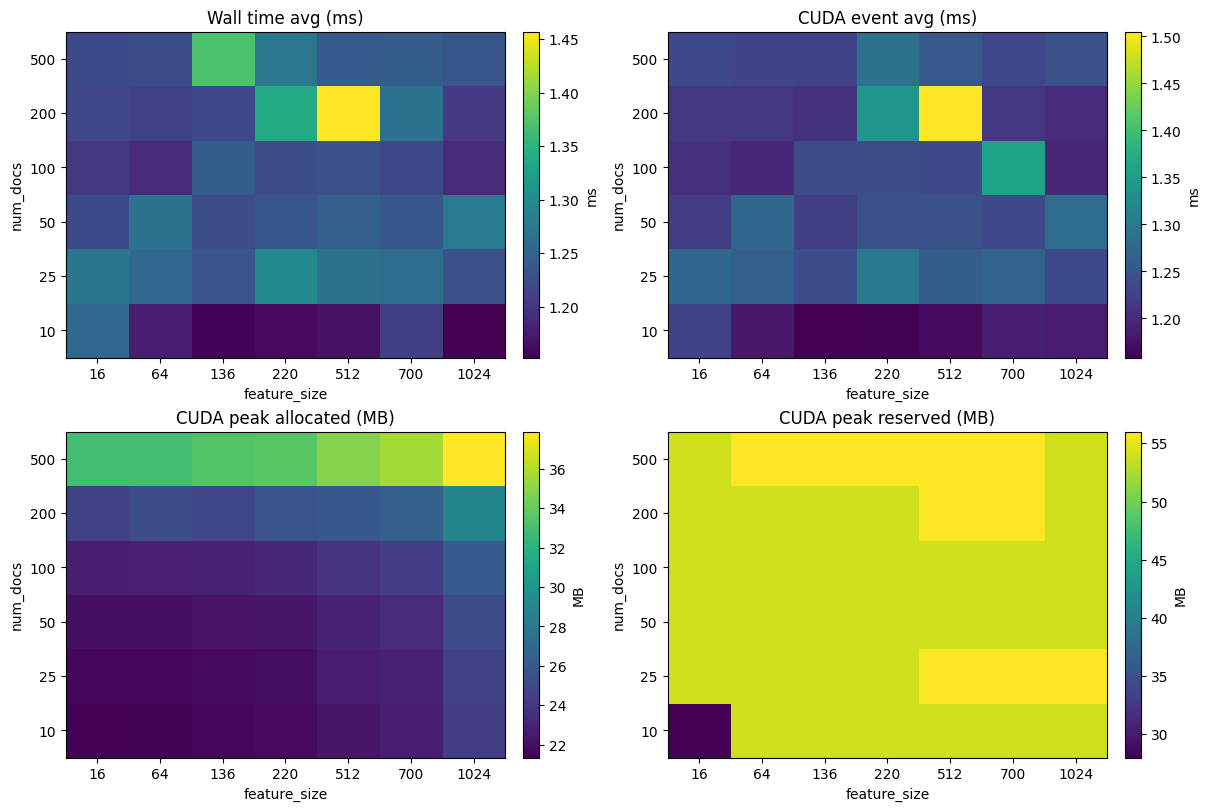

In [5]:
# Parameter grid (edit as needed)
doc_counts = [10, 25, 50, 100, 200, 500]
feature_sizes = [16, 64, 136, 220, 512, 700, 1024]
repeats = 20

# Storage
wall_ms_avg = np.zeros((len(doc_counts), len(feature_sizes)), dtype=float)
event_ms_avg = np.zeros_like(wall_ms_avg)
mem_alloc_mb = np.zeros_like(wall_ms_avg)  # CUDA allocated peak (MB)
mem_resv_mb = np.zeros_like(wall_ms_avg)   # CUDA reserved peak (MB)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Sweep
for i, nd in enumerate(doc_counts):
    for j, fs in enumerate(feature_sizes):
        model = make_Encoder_model(input_dim=fs)
        model.to(device)
        x = torch.randn((1, nd, fs), device=device)
        # Time
        t_res = measure_inference_time(model, x, repeats=repeats, use_cuda_events=True)
        wall_ms_avg[i, j] = t_res['wall_ms_avg']
        event_ms_avg[i, j] = t_res['event_ms_avg'] if t_res['event_ms_avg'] is not None else np.nan
        # Memory
        m_res = measure_inference_peak_memory(model, x, steps=3)
        alloc_b = m_res['cuda_peak']['allocated_bytes']
        resv_b = m_res['cuda_peak']['reserved_bytes']
        mem_alloc_mb[i, j] = alloc_b / (1024**2)
        mem_resv_mb[i, j] = resv_b / (1024**2)

# Plot helpers
def plot_heatmap(ax, Z, x_ticks, y_ticks, title, cbar_label):
    im = ax.imshow(Z, origin='lower', aspect='auto', cmap='viridis')
    ax.set_xticks(np.arange(len(x_ticks)))
    ax.set_xticklabels(x_ticks)
    ax.set_yticks(np.arange(len(y_ticks)))
    ax.set_yticklabels(y_ticks)
    ax.set_xlabel('feature_size')
    ax.set_ylabel('num_docs')
    ax.set_title(title)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
plot_heatmap(axes[0,0], wall_ms_avg, feature_sizes, doc_counts, 'Wall time avg (ms)', 'ms')
plot_heatmap(axes[0,1], event_ms_avg, feature_sizes, doc_counts, 'CUDA event avg (ms)', 'ms')
plot_heatmap(axes[1,0], mem_alloc_mb, feature_sizes, doc_counts, 'CUDA peak allocated (MB)', 'MB')
plot_heatmap(axes[1,1], mem_resv_mb, feature_sizes, doc_counts, 'CUDA peak reserved (MB)', 'MB')
plt.show()
fig.savefig('inference.pdf')